# 1 固定资产统计制度

固定资产是指企业为了生产经营而持有的、使用寿命超过一年的非货币性资产。典型的如厂房、机器设备、运输设备等。
固定资产投资就是指建造和购置这些固定资产的经济活动。

常用指标：**固定资产投资完成额**
即使一个建设进度只完成了60%的厂房，已经投入的各项费用和资产成本也都要计入固定资产投资完成额。

全社会固定资产完成额=农村住户固定资产投资 +固定资产投资（不含农户）

固定资产投资（不含农户）=城镇固定资产投资 +农村非农户投资

## 1.1 全社会固定资产投资核算方法

<!-- ![图1](./imgs/工业企业财务数据_1.png) -->

![图2](./imgs/工业企业财务数据_2.png)

## 1.2 固定资产投资价格指数核算方法

调查内容:

1. 建筑材料
2. 劳动力价格(单位工资)和各种施工机械的使用价格
3. 设备工器具购置和其他费用的价格

调查对象:

建筑,安装和装饰施工企业

固定资产投资价格指数已停止公布,所以可以用ppi代替

# 2 固定资产投资解读

国家统计局发布的固定资产投资额增长速度一般为名义增长速度。其他经济指标如 GDP、工业增加值等一般都使用扣除价格因素后的实际增长速度

## 2.1 总量分析

手动计算数据与官方数据存在差异:
- 2003-2004:统计范围发生变化
- 2011:统计限额从50万提升到500万,统计范围增加农村(非农户)投资部分
- 2018年至今:统计制度从形象进度法转向财务支出法

In [3]:
import akshare as ak
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json
import re
import math
import utils

# 指定支持中文的字体，例如SimHei或者Microsoft YaHei
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

figsize = (15,5)

In [4]:
dfGdzctz = ak.macro_china_nbs_nation(
    kind="月度数据", path="固定资产投资(不含农户)>固定资产投资概况", period="2000-"
)
dfGdzctz = dfGdzctz.transpose().iloc[::-1]

In [5]:
dfGdzctzzs1 = ak.macro_china_nbs_nation(
    kind="季度数据",
    path="价格指数>固定资产投资价格指数_累计值（上年同期=100）(-2018)",
    period="-2018",
)
dfGdzctzzs2 = ak.macro_china_nbs_nation(
    kind="季度数据",
    path="价格指数>固定资产投资价格指数_累计（上年同期=100）(2019-)",
    period="2019-",
)

In [6]:
dfGdzctzzs = pd.concat(
    [
        dfGdzctzzs1.transpose()["固定资产投资价格指数_累计值（上年同期=100）"].iloc[
            ::-1
        ],
        dfGdzctzzs2.transpose()["固定资产投资价格指数_累计值（上年同期=100）"].iloc[
            ::-1
        ],
    ]
)

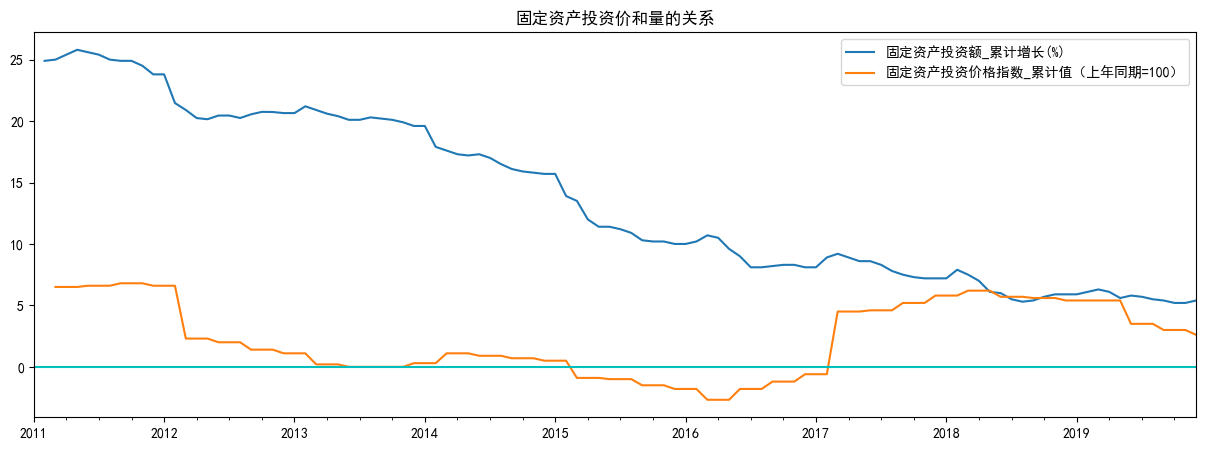

In [7]:
s1 = dfGdzctz["固定资产投资额_累计增长(%)"]
s1.index = utils.monthToDatatime(dfGdzctz.index)

s2 = dfGdzctzzs.copy()
s2.index = utils.quarterToDatatime(dfGdzctzzs.index)

df = pd.DataFrame(
    {
        "固定资产投资额_累计增长(%)": s1,
        "固定资产投资价格指数_累计值（上年同期=100）": s2 - 100,
    }
)

df.loc['2011':'2019'].ffill().plot(figsize=figsize)
plt.title('固定资产投资价和量的关系')
plt.axhline(y=0, c="c")

- 固定资产投资增速与经济景气程度和融资环境有关：经济越繁荣融资环境越宽松，增速越高。
- 2017年之后固定资产投资价格变动对固定资产投资的影响增大，甚至超过了量的影响
- 固定资产投资价格指数数据从2020年开始停止公布

## 2.2 结构分析

### 2.2.1 按行业划分

按主要行业分的全社会固定资产投资10-6：https://www.stats.gov.cn/sj/ndsj/2018/indexch.htm

按行业分固定资产投资（不含农户）10-12：https://www.stats.gov.cn/sj/ndsj/2018/indexch.htm

In [8]:
# 固定资产投资（不含农户）
df2017GdzctzByCategory = pd.DataFrame({
    "农、林、牧、渔业": 24638.3,
    "采矿业": 9208.9,
    "制造业": 193615.7,
    "电力、热力、燃气及水生产和供应业": 29794.1,
    "建筑业": 3647.9,
    "批发和零售业": 16541.8,
    "交通运输、仓储和邮政业": 61185.8,
    "住宿和餐饮业": 6106.6,
    "信息传输、软件和信息技术服务业": 6987.4,
    "金融业": 1121.5,
    "房地产业": 139733.5,
    "租赁和商务服务业": 13304.2,
    "科学研究和技术服务业": 5932.5,
    "水利、环境和公共设施管理业": 82105.3,
    "居民服务、修理和其他服务业": 2686.2,
    "教育": 11083.5,
    "卫生和社会工作": 7327.4,
    "文化、体育公共管理社会保障和娱乐业": 8731.9,
    "公共管理、社会保障和社会组织": 7931.3,
    "国际组织": 0,
}, index=[pd.to_datetime("2017", format="%Y")])

In [9]:
(df2017GdzctzByCategory / df2017GdzctzByCategory.iloc[0].sum() * 100).iloc[0].sort_values(axis=0, ascending=False)

制造业                  30.650731
房地产业                 22.120798
水利、环境和公共设施管理业        12.997848
交通运输、仓储和邮政业           9.686144
电力、热力、燃气及水生产和供应业      4.716616
农、林、牧、渔业              3.900417
批发和零售业                2.618684
租赁和商务服务业              2.106149
教育                    1.754596
采矿业                   1.457834
文化、体育公共管理社会保障和娱乐业     1.382321
公共管理、社会保障和社会组织        1.255581
卫生和社会工作               1.159979
信息传输、软件和信息技术服务业       1.106155
住宿和餐饮业                0.966718
科学研究和技术服务业            0.939157
建筑业                   0.577488
居民服务、修理和其他服务业         0.425244
金融业                   0.177541
国际组织                  0.000000
Name: 2017-01-01 00:00:00, dtype: float64

固定资产投资分为：
- 基建投资=交通运输仓储和邮政业+电力燃气及水的生产和供应业+水利环境和公共设施管理业
- 房地产投资
- 制造业
- 其他类投资


### 2.2.2 按建设性质划分

- 新建（50%）
- 扩建（11%）
- 改建（14%）
- 其他

### 2.2.3 按构成划分

按费用构成分:

- 建筑安装工程（70%）
- 设备工器具购置（16%）
- 其他费用（土地取得费用、前期工程费用、施工工作费用）（14%）

### 2.2.4 按登记注册类型划分

![固定资产投资_1.png](./imgs/固定资产投资_1.png)

民间固定资产投资完成额（2012年前）=总固定资产投资-国有及国有控股单位的投资额-外商和港澳台商投资企业的投资额

民间固定资产投资完成额（2012年后）=总固定资产投资-国有及国有控股单位的投资额-外商和港澳台商独资、控股企业的投资额



In [10]:
# 10-3 分地区按登记注册类型分全社会固定资产投资（2017） https://www.stats.gov.cn/sj/ndsj/2018/indexch.htm
df2017GdzctzByOwner = pd.DataFrame({
    "国有": 139073.3,
    "集体": 7678.5,
    "股份合作": 910.4,
    "联营": 664.1,
    "有限责任公司": 211642.8,
    "股份有限公司": 17304.4,
    "私营": 203474.9,
    "个体": 11804.0,
    "其他": 23769.7,
    "港、澳、台商投资": 13604.0,
    "外商投资": 11312.2
}, index=[pd.to_datetime("2017", format="%Y")])

In [11]:
(df2017GdzctzByOwner / df2017GdzctzByOwner.iloc[0].sum() * 100).iloc[0].sort_values(axis=0, ascending=False)

有限责任公司      33.005327
私营          31.731558
国有          21.688240
其他           3.706843
股份有限公司       2.698591
港、澳、台商投资     2.121520
个体           1.840813
外商投资         1.764118
集体           1.197449
股份合作         0.141975
联营           0.103565
Name: 2017-01-01 00:00:00, dtype: float64

In [12]:
dfMjgdzctz = ak.macro_china_nbs_nation(
    kind="月度数据", path="固定资产投资(不含农户)>固定资产投资概况", period="2011-"
)
dfGygdzctz = ak.macro_china_nbs_nation(
    kind="月度数据", path="固定资产投资(不含农户)>固定资产投资增速", period="2011-"
)

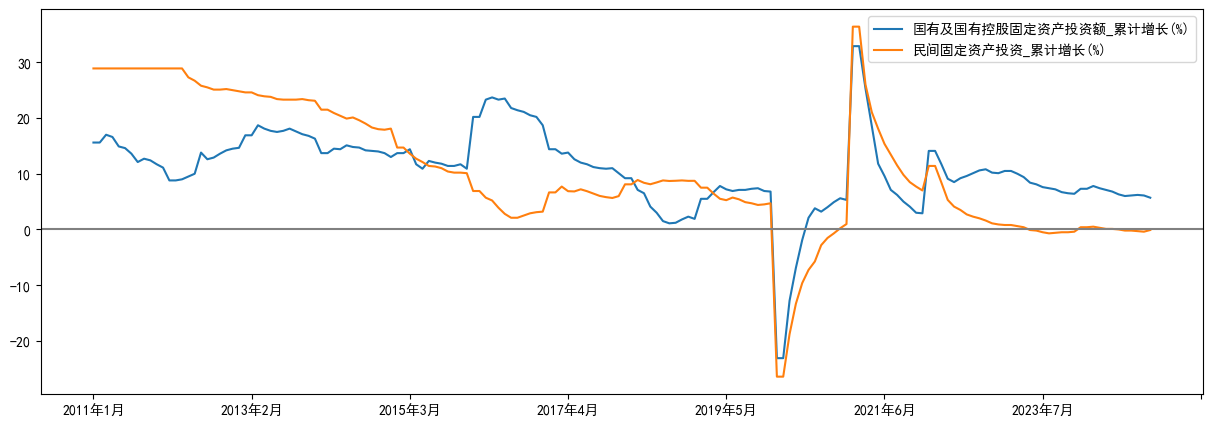

In [13]:

pd.DataFrame({
    "国有及国有控股固定资产投资额_累计增长(%)": dfGygdzctz.loc["国有及国有控股固定资产投资额_累计增长(%)"],
    "民间固定资产投资_累计增长(%)" : dfMjgdzctz.loc["民间固定资产投资_累计增长(%)"],
}).ffill().iloc[::-1].plot(figsize=figsize)

plt.axhline(y=0, c="gray")